SARIMA Modelle

Zuerst Nur AR

Dann nur MA

Dann ARIMA

Dann SARIMA

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
BASE_DIR = Path(r"C:\Users\nelid\Documents\Kaggle Competitions\Store Sales Competition\store-sales")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

In [3]:
# Modell auf einer Zeitreihe entwickeln - ein bestimmter Store und ein Family

train_part = pd.read_csv(PROCESSED_DIR / "train_lagged_train.csv", parse_dates=["date"])
val_part = pd.read_csv(PROCESSED_DIR / "train_lagged_val.csv", parse_dates=["date"])

In [4]:
store_id = 1
family_name = "GROCERY I"  # anpassen an die gewählte Serie

ts_df = train_part[(train_part["store_nbr"] == store_id) & (train_part["family"] == family_name)].copy()
ts_df = ts_df.sort_values("date")
ts = ts_df.set_index("date")["sales"]

# Frequenz setzen
ts = ts.asfreq("D")

# Transformation (Varianz stabilisieren), prozentuale Effekte linear modellieren; log1p berechnet log(1+x) und ist bei 0 defineirt
ts_log = np.log1p(ts)


### für den Val Datensatz

val_df = val_part[(val_part["store_nbr"] == store_id) & (val_part["family"] == family_name)].copy()
val_df = val_df.sort_values("date")
val = val_df.set_index("date")["sales"]

# Frequenz setzen
val = val.asfreq("D")

# Transformation (Varianz stabilisieren), prozentuale Effekte linear modellieren; log1p berechnet log(1+x) und ist bei 0 defineirt
val_log = np.log1p(val)


In [5]:
# Anfang mit einem nicht gemischten Modell, AR, d= 1, mit wöchentlicher Saisonalität

from statsmodels.tsa.statespace.sarimax import SARIMAX

order = (1, 1, 0) # AR, p = 1, d = 1, q = 0
seasonal_order = (1, 1, 0, 7) # s = 7

model = SARIMAX(
    ts_log,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results = model.fit(disp=False)
print(results.summary())


                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1642
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 7)   Log Likelihood               -1687.369
Date:                           Thu, 26 Feb 2026   AIC                           3380.738
Time:                                   12:03:24   BIC                           3396.919
Sample:                               01-01-2013   HQIC                          3386.742
                                    - 06-30-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4471      0.006    -76.740      0.000      -0.459      -0.436
ar.S.L7       -0.4125      0.004    -93.921

Schau auf niedrige Lags (1–10):

Ist z.B. Lag 1 im Residual‑ACF noch signifikant (über Konfidenzband)? → q um 1 erhöhen: (p,d,q) = (1,1,1) und Modell neu fitten.

Ist z.B. Lag 1 im Residual‑PACF signifikant? → p um 1 erhöhen: (p,d,q) = (2,1,0).

<Figure size 1000x400 with 0 Axes>

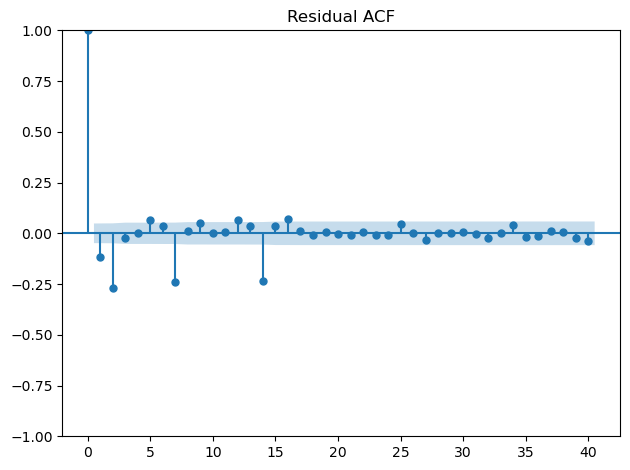

<Figure size 1000x400 with 0 Axes>

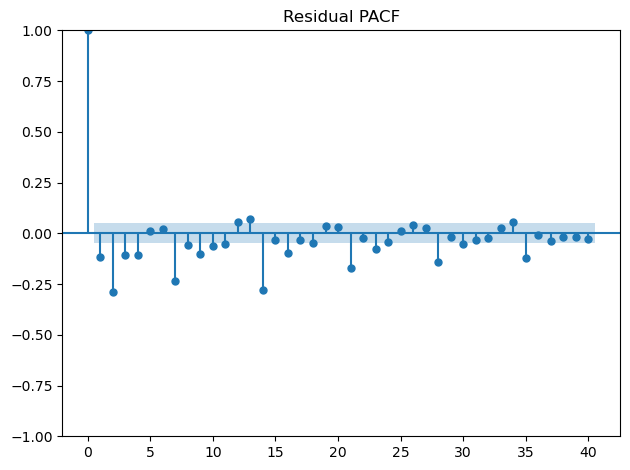

In [6]:
## ACF und PACF Plots anschauen

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

resid = results.resid.dropna()

plt.figure(figsize=(10, 4))
plot_acf(resid, lags=40)
plt.title("Residual ACF")
plt.tight_layout()

plt.figure(figsize=(10, 4))
plot_pacf(resid, lags=40, method="ywm")
plt.title("Residual PACF")
plt.tight_layout()


In [7]:
## Lag 1 ist im ACF Plot über dem Konfidenzband - MA (1) testen

order2 = (1, 1, 1)      # p=1, q=1 (ein gemischtes Modell, wenn okay für dich)
seasonal_order2 = (1, 1, 0, 7)

model2 = SARIMAX(
    ts_log,
    order=order2,
    seasonal_order=seasonal_order2,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results2 = model2.fit(disp=False)
print(results2.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                 1642
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 7)   Log Likelihood               -1431.977
Date:                            Thu, 26 Feb 2026   AIC                           2871.953
Time:                                    12:03:27   BIC                           2893.529
Sample:                                01-01-2013   HQIC                          2879.958
                                     - 06-30-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1580      0.020      7.761      0.000       0.118       0.198
ma.L1         -1.0000      1.244   

In [8]:
## MA Weglassen, AR um 1 erhöhen

order3 = (2, 1, 0)
seasonal_order3 = (1, 1, 0, 7)

model3 = SARIMAX(
    ts_log,
    order=order3,
    seasonal_order=seasonal_order3,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results3 = model3.fit(disp=False)
print(results3.summary())


                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1642
Model:             SARIMAX(2, 1, 0)x(1, 1, 0, 7)   Log Likelihood               -1608.294
Date:                           Thu, 26 Feb 2026   AIC                           3224.588
Time:                                   12:03:28   BIC                           3246.161
Sample:                               01-01-2013   HQIC                          3232.593
                                    - 06-30-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5862      0.008    -73.963      0.000      -0.602      -0.571
ar.L2         -0.2977      0.009    -31.545

In [9]:
# Komplexeres Modell. Leider overfit
order = (2, 1, 1)
seasonal_order = (1, 1, 1, 7)

model_211_111 = SARIMAX(
    ts_log,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results_211_111 = model_211_111.fit(disp=False)
print(results_211_111.summary())


                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1642
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -1114.220
Date:                           Thu, 26 Feb 2026   AIC                           2240.439
Time:                                   12:03:32   BIC                           2272.799
Sample:                               01-01-2013   HQIC                          2252.446
                                    - 06-30-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1325      0.015      8.954      0.000       0.103       0.161
ar.L2          0.0269      0.033      0.810

In [10]:
## Loggen der Experimente soweit

import mlflow
from pathlib import Path

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("store-sales-sarima")


<Experiment: artifact_location=('file:///C:/Users/nelid/Documents/Kaggle Competitions/Store Sales '
 'Competition/store-sales/mlruns/1'), creation_time=1772014875182, experiment_id='1', last_update_time=1772014875182, lifecycle_stage='active', name='store-sales-sarima', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [11]:
## Wichtigstes KPI: Root mean squared log error

from sklearn.metrics import mean_squared_log_error

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

In [12]:
from sklearn.metrics import mean_squared_error
import sklearn
print(sklearn.__version__)

1.8.0


In [13]:
import inspect
print(mean_squared_error)
print(inspect.getsource(mean_squared_error))


<function mean_squared_error at 0x000001C593681C60>
@validate_params(
    {
        "y_true": ["array-like"],
        "y_pred": ["array-like"],
        "sample_weight": ["array-like", None],
        "multioutput": [StrOptions({"raw_values", "uniform_average"}), "array-like"],
    },
    prefer_skip_nested_validation=True,
)
def mean_squared_error(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput="uniform_average",
):
    """Mean squared error regression loss.

    Read more in the :ref:`User Guide <mean_squared_error>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,) or (n_samples, n_outputs)
        Ground truth (correct) target values.

    y_pred : array-like of shape (n_samples,) or (n_samples, n_outputs)
        Estimated target values.

    sample_weight : array-like of shape (n_samples,), default=None
        Sample weights.

    multioutput : {'raw_values', 'uniform_average'} or array-like of shape \
            (n_outputs,), d

In [13]:

# import matplotlib.pyplot as plt
# import mlflow
# from statsmodels.tsa.statespace.sarimax import SARIMAX

# 4) Benchmark-SARIMA fitten un din MLFlow loggen
order = (1, 1, 1)
seasonal_order = (1, 1, 0, 7)

model = SARIMAX(
    ts_log,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results = model.fit(disp=False)

# 5) Forecast auf Validierungsfenster
pred = results.get_prediction(start=val_log.index[0], end=val_log.index[-1])
pred_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_val = np.expm1(pred_log)
val_actual = np.expm1(val_log)


rmse = mean_squared_error(val_actual, pred_val) ## wichtig: ohne , squared=False
mape = (np.abs(val_actual - pred_val) / val_actual).mean()
rmsle_val = rmsle(val_actual, pred_val)

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"RMSLE: {rmsle_val:.5f}")

# 6) Forecast-Plot erzeugen (für Artifact)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts_log.index, np.expm1(ts_log), label="Train")
ax.plot(val_actual.index, val_actual, label="Val actual", color="black")
ax.plot(pred_val.index, pred_val, label="SARIMA forecast", color="red")
ax.legend()
ax.set_title(f"SARIMA(1,1,1)x(1,1,0,7) – store {store_id}, family {family_name}")
fig.tight_layout()
plot_path = PROCESSED_DIR / f"sarima_{store_id}_{family_name}_val_forecast.png"
fig.savefig(plot_path)
plt.close(fig)

# 7) In MLflow loggen
with mlflow.start_run(run_name="SARIMA_1_1_1_x_1_1_0_7"):
    # Parameter
    mlflow.log_param("model_type", "SARIMAX")
    mlflow.log_param("p", order[0])
    mlflow.log_param("d", order[1])
    mlflow.log_param("q", order[2])
    mlflow.log_param("P", seasonal_order[0])
    mlflow.log_param("D", seasonal_order[1])
    mlflow.log_param("Q", seasonal_order[2])
    mlflow.log_param("s", seasonal_order[3])
    mlflow.log_param("store_nbr", store_id)
    mlflow.log_param("family", family_name)

    # Metriken
    mlflow.log_metric("rmse_val", rmse)
    mlflow.log_metric("mape_val", float(mape))
    mlflow.log_metric("rmsle_val", float(rmsle_val)) 
    mlflow.log_metric("aic", results.aic)
    mlflow.log_metric("bic", results.bic)

    # Artefakte
    mlflow.log_artifact(str(plot_path))

RMSE: 214536.94
MAPE: 16.36%
RMSLE: 0.20652


NameError: name 'mlflow' is not defined

- Wir haben jetzt ein lokales Benchmark-Modell. Im nächsten Schritt berechnen wir ein globales Benchmark-Modell und vergleichen die Ergebnisse für diese Referenzkategorie. 

In [14]:
## LightGBM global baseline

# import pandas as pd
# import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor
# from sklearn.metrics import mean_squared_error

# import mlflow
import mlflow.lightgbm



In [15]:
train_part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918916 entries, 0 to 2918915
Data columns (total 57 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   id                       int64         
 1   date                     datetime64[ns]
 2   store_nbr                int64         
 3   family                   object        
 4   sales                    float64       
 5   onpromotion              int64         
 6   year                     int64         
 7   month                    int64         
 8   day                      int64         
 9   dayofweek                int64         
 10  weekofyear               int64         
 11  dayofyear                int64         
 12  is_weekend               int64         
 13  city                     object        
 14  state                    object        
 15  type                     object        
 16  cluster                  int64         
 17  transactions             fl

In [16]:
# import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
# import mlflow
import mlflow.lightgbm

# Annahme: train_part, val_part existieren bereits als DataFrames

target_col = "sales"

cat_cols = ["store_nbr", "family", "city", "state", "type", "cluster", "holiday_names"]

num_cols = [
    "onpromotion",
    "year", "month", "day", "dayofweek", "weekofyear", "dayofyear",
    "is_weekend",
    "transactions",
    "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_21", "sales_lag_28",
    "sales_rmean_lag1_win7", "sales_rmean_lag1_win14", "sales_rmean_lag1_win28",
    "sales_rmean_lag1_win56", "sales_rmean_lag1_win90",
    "sales_rmean_lag7_win7", "sales_rmean_lag7_win14", "sales_rmean_lag7_win28",
    "sales_rmean_lag7_win56", "sales_rmean_lag7_win90",
    "sales_rmean_lag14_win7", "sales_rmean_lag14_win14", "sales_rmean_lag14_win28",
    "sales_rmean_lag14_win56", "sales_rmean_lag14_win90",
    "sales_rmean_lag21_win7", "sales_rmean_lag21_win14", "sales_rmean_lag21_win28",
    "sales_rmean_lag21_win56", "sales_rmean_lag21_win90",
    "sales_rmean_lag28_win7", "sales_rmean_lag28_win14", "sales_rmean_lag28_win28",
    "sales_rmean_lag28_win56", "sales_rmean_lag28_win90",
    "is_holiday_observed", "is_additional_holiday", "is_bridge_day",
    "is_work_day_comp", "is_transferred_flag", "is_holiday_weekend",
    "log_sales", "sales_per_transaction",
]

feature_cols = cat_cols + num_cols


In [17]:
## Encoding und Matrix bauen

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1) # Die kategorialen Features im Datensatz sind nicht ordinal. 
# Für Baum‑Modelle ist die künstliche Ordnung dieser IDs in der Regel unkritisch, weil der Baum nicht die numerische Größe interpretiert, sondern optimale Splits über die Werte findet

train_part_enc = train_part.copy()
val_part_enc = val_part.copy()

train_part_enc[cat_cols] = enc.fit_transform(train_part_enc[cat_cols])
val_part_enc[cat_cols] = enc.transform(val_part_enc[cat_cols])

X_train = train_part_enc[feature_cols]
y_train = train_part_enc[target_col]

X_val = val_part_enc[feature_cols]
y_val = val_part_enc[target_col]


In [23]:
## Metriken und ML-Flow loggen

def rmsle(y_true, y_pred):
    y_true_c = np.maximum(y_true, 0)
    y_pred_c = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred_c) - np.log1p(y_true_c))**2))

def mape(y_true, y_pred):
    y_true_c = np.where(y_true == 0, 1e-6, y_true) # Ersetze 0 mit einem sehr kleinen Wert, damit REchnung laufen kann
    return np.mean(np.abs(y_true - y_pred) / y_true_c) * 100

# mlflow.set_experiment("store_sales_global_baseline")

with mlflow.start_run(run_name="lgbm_global_baseline_trainpart_valpart"):
    params = {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": -1,
        "num_leaves": 64,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "n_jobs": -1,
    }
    mlflow.log_params(params)

    model = LGBMRegressor(**params)
    mlflow.lightgbm.autolog(disable=True)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
    )

    # Vorhersage
    val_part_enc["pred"] = model.predict(X_val)

    # Globale KPIs
    rmse_global = mean_squared_error(y_val, val_part_enc["pred"])
    mape_global = mape(y_val.values, val_part_enc["pred"].values)
    rmsle_global = rmsle(y_val.values, val_part_enc["pred"].values)

    mlflow.log_metric("rmse_global", rmse_global)
    mlflow.log_metric("mape_global", mape_global)
    mlflow.log_metric("rmsle_global", rmsle_global)

    # Per Store-Family KPIs
    group_cols = ["store_nbr", "family"]
    per_series = (
        val_part_enc
        .groupby(group_cols)
        .apply(
            lambda g: pd.Series({
                "rmse": mean_squared_error(g[target_col], g["pred"]),
                "mape": mape(g[target_col].values, g["pred"].values),
                "rmsle": rmsle(g[target_col].values, g["pred"].values),
                "n_samples": len(g),
            })
        )
        .reset_index()
    )

    mlflow.log_metric("rmse_series_mean", per_series["rmse"].mean())
    mlflow.log_metric("mape_series_mean", per_series["mape"].mean())
    mlflow.log_metric("rmsle_series_mean", per_series["rmsle"].mean())

    # Top-10 best & worst nach RMSLE
    top10_best = per_series.nsmallest(10, "rmsle")
    top10_worst = per_series.nlargest(10, "rmsle")

    import os
    os.makedirs("artifacts", exist_ok=True)
    best_path = "artifacts/top10_best_series.csv"
    worst_path = "artifacts/top10_worst_series.csv"

    top10_best.to_csv(best_path, index=False)
    top10_worst.to_csv(worst_path, index=False)

    mlflow.log_artifact(best_path, artifact_path="analysis")
    mlflow.log_artifact(worst_path, artifact_path="analysis")

    mlflow.lightgbm.log_model(model, artifact_path="model")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.427229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9242
[LightGBM] [Info] Number of data points in the train set: 2918916, number of used features: 54
[LightGBM] [Info] Start training from score 354.309666


C:\Users\nelid\AppData\Local\Temp\ipykernel_40824\2995855206.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
2026/02/25 16:43:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 16:43:03 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.


🏃 View run lgbm_global_baseline_trainpart_valpart at: http://127.0.0.1:5000/#/experiments/1/runs/bff25dd09836499cab8f2bfc06fca10f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [24]:
top10_best

,store_nbr,family,rmse,mape,rmsle,n_samples
499,15.0,4.0,0.049633,2.226746e+07,0.0,46.0
514,15.0,19.0,0.049633,2.226746e+07,0.0,46.0
515,15.0,20.0,0.049633,2.226746e+07,0.0,46.0
526,15.0,31.0,0.049633,2.226746e+07,0.0,46.0
697,21.0,4.0,0.047819,2.170098e+07,0.0,46.0
713,21.0,20.0,0.047819,2.170098e+07,0.0,46.0
826,25.0,1.0,0.049693,2.229203e+07,0.0,46.0
829,25.0,4.0,0.049693,2.229203e+07,0.0,46.0
961,29.0,4.0,0.049481,2.223758e+07,0.0,46.0
977,29.0,20.0,0.049481,2.223758e+07,0.0,46.0


In [25]:
top10_worst

,store_nbr,family,rmse,mape,rmsle,n_samples
1420,43.0,1.0,1.955408,1.392500e+08,0.872545,46.0
1423,43.0,4.0,1.884618,1.323955e+08,0.852870,46.0
1453,44.0,1.0,1.593205,1.251632e+08,0.812284,46.0
1519,46.0,1.0,1.570116,1.244851e+08,0.809133,46.0
1456,44.0,4.0,1.567790,1.226275e+08,0.804776,46.0
1522,46.0,4.0,1.491289,1.166622e+08,0.785423,46.0
1486,45.0,1.0,1.240183,1.089984e+08,0.739180,46.0
1436,43.0,17.0,1.439510,8.708264e+07,0.707744,46.0
70,2.0,4.0,0.957455,9.667310e+07,0.677725,46.0
1489,45.0,4.0,1.039346,8.846074e+07,0.669245,46.0


In [28]:
# Feature Importances anschauen
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_,
})

importances = importances.sort_values("importance", ascending=False)

print(importances.head(30))

                    feature  importance
52                log_sales        4089
15             transactions        4035
53    sales_per_transaction        3158
17              sales_lag_7        1694
7               onpromotion        1667
21    sales_rmean_lag1_win7        1448
18             sales_lag_14        1362
6             holiday_names        1350
16              sales_lag_1        1256
10                      day        1229
13                dayofyear         978
0                 store_nbr         854
20             sales_lag_28         853
19             sales_lag_21         737
11                dayofweek         633
12               weekofyear         602
22   sales_rmean_lag1_win14         581
26    sales_rmean_lag7_win7         388
5                   cluster         384
31   sales_rmean_lag14_win7         366
36   sales_rmean_lag21_win7         307
41   sales_rmean_lag28_win7         293
27   sales_rmean_lag7_win14         254
23   sales_rmean_lag1_win28         216


In [18]:
family_categories = enc.categories_[cat_cols.index("family")]
print(family_categories[:20])  # erste 20 Families

idx = np.where(family_categories == "GROCERY I")[0]
print(idx)

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR']
[12]


In [34]:
store_id = 1
family = 12 # "GROCERY I"  

row_sarima_series = per_series.query(
    "store_nbr == @store_id and family == @family"
)

if row_sarima_series.empty:
    raise ValueError("Keine passende Serie in per_series gefunden. Prüfe store_nbr/family.")

row_sarima_series = row_sarima_series.iloc[0]

rmsle_lgbm_series_1_1 = row_sarima_series["rmsle"]
rmse_lgbm_series_1_1 = row_sarima_series["rmse"]
mape_lgbm_series_1_1 = row_sarima_series["mape"]
n_lgbm_series_1_1 = int(row_sarima_series["n_samples"])

print(rmsle_lgbm_series_1_1, rmse_lgbm_series_1_1 , mape_lgbm_series_1_1 , n_lgbm_series_1_1)


0.02844322336485425 20550.131027452786 1.9418487836712244 46


In [39]:
### Hier XGBoost probieren und loggen

import xgboost as xgb
# import mlflow
import mlflow.xgboost
# from sklearn.metrics import mean_squared_error
# import numpy as np

def rmsle(y_true, y_pred):
    y_true_c = np.maximum(y_true, 0)
    y_pred_c = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred_c) - np.log1p(y_true_c))**2))

def mape(y_true, y_pred):
    y_true_c = np.where(y_true == 0, 1e-6, y_true)
    return np.mean(np.abs(y_true - y_pred) / y_true_c) * 100

#X_train = train_enc[feature_cols]
#X_val = val_enc[feature_cols]

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "alpha": 0.0,
    "tree_method": "hist",  # ggf. "gpu_hist"
}

mlflow.set_experiment("store-sales-sarima")

with mlflow.start_run(run_name="xgboost_global_baseline_all_features"):
    mlflow.log_params(params)

    watchlist = [(dtrain, "train"), (dval, "valid")]
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=watchlist,
        early_stopping_rounds=50,
        verbose_eval=50,
    )

    y_pred_val = model.predict(dval)

    rmse_global = mean_squared_error(y_val, y_pred_val)
    mape_global = mape(y_val.values, y_pred_val)
    rmsle_global = rmsle(y_val.values, y_pred_val)

    mlflow.log_metric("rmse_global", rmse_global)
    mlflow.log_metric("mape_global", mape_global)
    mlflow.log_metric("rmsle_global", rmsle_global)

    # Per-Store-Family KPIs wie bei LGBM
    val_tmp = val_part_enc.copy()
    val_tmp["pred"] = y_pred_val

    group_cols = ["store_nbr", "family"]
    per_series_xgb = (
        val_tmp
        .groupby(group_cols)
        .apply(
            lambda g: pd.Series({
                "rmse": mean_squared_error(g["sales"], g["pred"]),
                "mape": mape(g["sales"].values, g["pred"].values),
                "rmsle": rmsle(g["sales"].values, g["pred"].values),
                "n_samples": len(g),
            })
        )
        .reset_index()
    )

    mlflow.log_metric("rmse_series_mean", per_series_xgb["rmse"].mean())
    mlflow.log_metric("mape_series_mean", per_series_xgb["mape"].mean())
    mlflow.log_metric("rmsle_series_mean", per_series_xgb["rmsle"].mean())

    # Feature Importances + Top10 best/worst analog zu LGBM loggen
   # Top-10 best & worst nach RMSLE
    top10_best_xgb = per_series_xgb.nsmallest(10, "rmsle")
    top10_worst_xgb = per_series_xgb.nlargest(10, "rmsle")

    import os
    os.makedirs("artifacts", exist_ok=True)
    best_path = "artifacts/top10_best_series_xgb.csv"
    worst_path = "artifacts/top10_worst_series_xgb.csv"

    top10_best_xgb.to_csv(best_path, index=False)
    top10_worst_xgb.to_csv(worst_path, index=False)

    mlflow.log_artifact(best_path, artifact_path="analysis")
    mlflow.log_artifact(worst_path, artifact_path="analysis")

    
    mlflow.xgboost.log_model(model, artifact_path="model")


[0]	train-rmse:1041.16444	valid-rmse:1258.11664
[50]	train-rmse:120.66412	valid-rmse:110.45037
[100]	train-rmse:67.53726	valid-rmse:63.59669
[150]	train-rmse:54.34417	valid-rmse:63.60833
[171]	train-rmse:51.02052	valid-rmse:64.86320


C:\Users\nelid\AppData\Local\Temp\ipykernel_40824\284705849.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
2026/02/26 11:39:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run xgboost_global_baseline_all_features at: http://127.0.0.1:5000/#/experiments/1/runs/72f39c39d7b8454eabb2aad1892b35e5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [45]:
# Log für die Einzelserie xgb

store_id = 1
family = 12 # "GROCERY I"  

row_sarima_series = per_series_xgb.query(
    "store_nbr == @store_id and family == @family"
)

if row_sarima_series.empty:
    raise ValueError("Keine passende Serie in per_series gefunden. Prüfe store_nbr/family.")

row_sarima_series = row_sarima_series.iloc[0]

rmsle_xgb_series_1_1 = row_sarima_series["rmsle"]
rmse_xgb_series_1_1 = row_sarima_series["rmse"]
mape_xgb_series_1_1 = row_sarima_series["mape"]
n_xgb_series_1_1 = int(row_sarima_series["n_samples"])

print(rmsle_xgb_series_1_1, rmse_xgb_series_1_1 , mape_xgb_series_1_1 , n_xgb_series_1_1)

0.022505293650356934 10166.357423207035 1.8374111923501346 46


In [40]:
top10_best_xgb

,store_nbr,family,rmse,mape,rmsle,n_samples
1381,41.0,28.0,3.873780,0.621598,0.007375,46.0
75,2.0,9.0,9.275157,0.605161,0.007780,46.0
391,11.0,28.0,1.865885,0.661527,0.007932,46.0
546,16.0,18.0,9.610446,0.656737,0.008156,46.0
434,13.0,5.0,2.021533,0.709384,0.008220,46.0
952,28.0,28.0,2.797941,0.662297,0.008306,46.0
372,11.0,9.0,3.996607,0.694777,0.008354,46.0
1216,36.0,28.0,4.851764,0.702130,0.008365,46.0
688,20.0,28.0,2.254554,0.695402,0.008419,46.0
1734,52.0,18.0,4.096649,0.728386,0.008488,46.0


In [41]:
top10_worst_xgb

,store_nbr,family,rmse,mape,rmsle,n_samples
1420,43.0,1.0,0.365239,6.014388e+07,0.471648,46.0
1423,43.0,4.0,0.347490,5.731218e+07,0.460084,46.0
1453,44.0,1.0,0.297969,5.435521e+07,0.434789,46.0
1519,46.0,1.0,0.294730,5.408259e+07,0.432947,46.0
1456,44.0,4.0,0.291829,5.319607e+07,0.430210,46.0
1522,46.0,4.0,0.279806,5.073536e+07,0.420130,46.0
1486,45.0,1.0,0.229160,4.704164e+07,0.388466,46.0
1436,43.0,17.0,0.259773,3.811657e+07,0.379292,46.0
70,2.0,4.0,0.184167,4.232366e+07,0.355196,46.0
1489,45.0,4.0,0.194584,3.890670e+07,0.354271,46.0


In [44]:
# Feature Importances anschauen
# import pandas as pd

import pandas as pd

score = model.get_score(importance_type="gain")  # oder "weight", "cover"

imp_df = (
    pd.DataFrame(
        [(k, v) for k, v in score.items()],
        columns=["feature", "importance"],
    )
    .sort_values("importance", ascending=False)
)

print(imp_df.head(30))



                    feature    importance
52                log_sales  4.600897e+09
21    sales_rmean_lag1_win7  1.355101e+09
17              sales_lag_7  2.622508e+08
18             sales_lag_14  1.900745e+08
46      is_holiday_observed  1.570179e+08
53    sales_per_transaction  8.671660e+07
6             holiday_names  8.037744e+07
15             transactions  7.169026e+07
0                 store_nbr  5.934653e+07
3                     state  5.190175e+07
16              sales_lag_1  4.828947e+07
23   sales_rmean_lag1_win28  4.469184e+07
2                      city  4.428725e+07
36   sales_rmean_lag21_win7  4.163884e+07
33  sales_rmean_lag14_win28  4.127731e+07
11                dayofweek  4.000888e+07
7               onpromotion  3.928490e+07
26    sales_rmean_lag7_win7  3.639092e+07
19             sales_lag_21  3.274736e+07
25   sales_rmean_lag1_win90  3.175781e+07
14               is_weekend  3.048413e+07
5                   cluster  2.929554e+07
45  sales_rmean_lag28_win90  2.908

In [21]:
### Hier CatBoost versuchen:

from catboost import CatBoostRegressor
# import mlflow
import mlflow.catboost
# import numpy as np
# import pandas as pd
# from sklearn.metrics import mean_squared_error

def rmsle(y_true, y_pred):
    y_true_c = np.maximum(y_true, 0)
    y_pred_c = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred_c) - np.log1p(y_true_c))**2))

def mape(y_true, y_pred):
    y_true_c = np.where(y_true == 0, 1e-6, y_true)
    return np.mean(np.abs(y_true - y_pred) / y_true_c) * 100

# falls du die kategorialen Spalten als int-codes hast:
cat_cols = ["store_nbr", "family", "city", "state", "type", "cluster", "holiday_names"]

# Kategorische Spalten in int casten (oder str, wenn dir lieber)
for c in cat_cols:
    # falls es floats sind, auf int konvertieren
    train_part_enc[c] = train_part_enc[c].astype(int)
    val_part_enc[c] = val_part_enc[c].astype(int)

X_train = train_part_enc[feature_cols]
X_val = val_part_enc[feature_cols]

# Indizes der kategorialen Features relativ zu feature_cols
cat_feature_indices = [feature_cols.index(c) for c in cat_cols]

model = CatBoostRegressor(**params)

model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_feature_indices,
    use_best_model=True,
    early_stopping_rounds=50,
)





params = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 8,
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": 42,
    "bagging_temperature": 1.0,
    "l2_leaf_reg": 3.0,
    "thread_count": -1,
    "verbose": 50,
}

mlflow.set_experiment("store-sales-sarima")

with mlflow.start_run(run_name="catboost_global_baseline_all_features"):
    mlflow.log_params(params)

    model = CatBoostRegressor(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_feature_indices,
        use_best_model=True,
        early_stopping_rounds=50,
    )

    y_pred_val = model.predict(X_val)

    rmse_global = mean_squared_error(y_val, y_pred_val)
    mape_global = mape(y_val.values, y_pred_val)
    rmsle_global = rmsle(y_val.values, y_pred_val)

    mlflow.log_metric("rmse_global", rmse_global)
    mlflow.log_metric("mape_global", mape_global)
    mlflow.log_metric("rmsle_global", rmsle_global)

    # Per-Store-Family KPIs wie bei LGBM/XGB
    val_tmp = val_part_enc.copy()
    val_tmp["pred"] = y_pred_val

    group_cols = ["store_nbr", "family"]
    per_series_cb = (
        val_tmp
        .groupby(group_cols)
        .apply(
            lambda g: pd.Series({
                "rmse": mean_squared_error(g["sales"], g["pred"]),
                "mape": mape(g["sales"].values, g["pred"].values),
                "rmsle": rmsle(g["sales"].values, g["pred"].values),
                "n_samples": len(g),
            })
        )
        .reset_index()
    )

    mlflow.log_metric("rmse_series_mean", per_series_cb["rmse"].mean())
    mlflow.log_metric("mape_series_mean", per_series_cb["mape"].mean())
    mlflow.log_metric("rmsle_series_mean", per_series_cb["rmsle"].mean())

    # Top-10 best & worst nach RMSLE
    top10_best_cb = per_series_cb.nsmallest(10, "rmsle")
    top10_worst_cb = per_series_cb.nlargest(10, "rmsle")

    import os
    os.makedirs("artifacts", exist_ok=True)
    best_path = "artifacts/top10_best_series_catboost.csv"
    worst_path = "artifacts/top10_worst_series_catboost.csv"

    top10_best_cb.to_csv(best_path, index=False)
    top10_worst_cb.to_csv(worst_path, index=False)

    mlflow.log_artifact(best_path, artifact_path="analysis")
    mlflow.log_artifact(worst_path, artifact_path="analysis")

    mlflow.catboost.log_model(model, artifact_path="model")


0:	learn: 1042.5420648	test: 1259.8560812	best: 1259.8560812 (0)	total: 5.84s	remaining: 1h 37m 17s
50:	learn: 159.5622254	test: 127.0502182	best: 127.0502182 (50)	total: 3m 9s	remaining: 58m 52s
100:	learn: 110.0918423	test: 64.4660609	best: 64.4660609 (100)	total: 6m 9s	remaining: 54m 53s
150:	learn: 99.3830966	test: 64.2495451	best: 63.5942456 (109)	total: 9m 13s	remaining: 51m 51s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 63.59424565
bestIteration = 109

Shrink model to first 110 iterations.
0:	learn: 1042.5420648	test: 1259.8560812	best: 1259.8560812 (0)	total: 3.61s	remaining: 1h 5s
50:	learn: 159.5622254	test: 127.0502182	best: 127.0502182 (50)	total: 3m 10s	remaining: 59m 8s
100:	learn: 110.0918423	test: 64.4660609	best: 64.4660609 (100)	total: 6m 12s	remaining: 55m 13s
150:	learn: 99.3830966	test: 64.2495451	best: 63.5942456 (109)	total: 9m 11s	remaining: 51m 41s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 63.59424565
bestIteration

C:\Users\nelid\AppData\Local\Temp\ipykernel_42856\4035086151.py:96: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
2026/02/26 12:30:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run catboost_global_baseline_all_features at: http://127.0.0.1:5000/#/experiments/1/runs/da963ad4559940cdb172f20dade1e9cf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [23]:
## Soweit ist XGBoost am besten. Hyperparameter tunen

import xgboost as xgb
# import numpy as np
# from sklearn.metrics import mean_squared_error
# import mlflow
# import mlflow.xgboost

def rmsle(y_true, y_pred):
    y_true_c = np.maximum(y_true, 0)
    y_pred_c = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred_c) - np.log1p(y_true_c))**2))

def mape(y_true, y_pred):
    y_true_c = np.where(y_true == 0, 1e-6, y_true)
    return np.mean(np.abs(y_true - y_pred) / y_true_c) * 100

# Annahme: X_train, X_val, y_train, y_val, val_part_enc existieren
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

param_grid = [
    {"max_depth": 6, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 8, "min_child_weight": 1, "subsample": 0.9, "colsample_bytree": 0.8},
    {"max_depth": 8, "min_child_weight": 5, "subsample": 0.8, "colsample_bytree": 0.9},
    {"max_depth": 10, "min_child_weight": 3, "subsample": 0.9, "colsample_bytree": 0.9},
]

base_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "lambda": 1.0,
    "alpha": 0.0,
    "tree_method": "hist",
}

mlflow.set_experiment("store-sales-sarima")

for i, p in enumerate(param_grid):
    params = {**base_params, **p}

    with mlflow.start_run(run_name=f"xgb_tune_{i}"):
        mlflow.log_params(params)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=2000,
            evals=[(dtrain, "train"), (dval, "valid")],
            early_stopping_rounds=100,
            verbose_eval=100,
        )

        y_pred_val = model.predict(dval)

        # Globale KPIs
        rmse_global = mean_squared_error(y_val, y_pred_val)
        mape_global = mape(y_val.values, y_pred_val)
        rmsle_global = rmsle(y_val.values, y_pred_val)

        mlflow.log_metric("rmse_global", rmse_global)
        mlflow.log_metric("mape_global", mape_global)
        mlflow.log_metric("rmsle_global", rmsle_global)

        # Per-Store-Family KPIs wie bisher
        val_tmp = val_part_enc.copy()
        val_tmp["pred"] = y_pred_val

        group_cols = ["store_nbr", "family"]
        per_series_xgb = (
            val_tmp
            .groupby(group_cols)
            .apply(
                lambda g: pd.Series({
                    "rmse": mean_squared_error(g["sales"], g["pred"]),
                    "mape": mape(g["sales"].values, g["pred"].values),
                    "rmsle": rmsle(g["sales"].values, g["pred"].values),
                    "n_samples": len(g),
                })
            )
            .reset_index()
        )

        mlflow.log_metric("rmse_series_mean", per_series_xgb["rmse"].mean())
        mlflow.log_metric("mape_series_mean", per_series_xgb["mape"].mean())
        mlflow.log_metric("rmsle_series_mean", per_series_xgb["rmsle"].mean())

        # Top-10 best & worst nach RMSLE
        top10_best_xgb = per_series_xgb.nsmallest(10, "rmsle")
        top10_worst_xgb = per_series_xgb.nlargest(10, "rmsle")

        import os
        os.makedirs("artifacts", exist_ok=True)
        best_path = f"artifacts/top10_best_series_xgb_tune_{i}.csv"
        worst_path = f"artifacts/top10_worst_series_xgb_tune_{i}.csv"

        top10_best_xgb.to_csv(best_path, index=False)
        top10_worst_xgb.to_csv(worst_path, index=False)

        mlflow.log_artifact(best_path, artifact_path="analysis")
        mlflow.log_artifact(worst_path, artifact_path="analysis")

        mlflow.xgboost.log_model(model, artifact_path="model")



[0]	train-rmse:1041.31812	valid-rmse:1258.21210
[100]	train-rmse:94.60116	valid-rmse:67.28747
[200]	train-rmse:76.27143	valid-rmse:66.41469
[300]	train-rmse:60.89827	valid-rmse:62.07733
[400]	train-rmse:47.90440	valid-rmse:61.96207
[428]	train-rmse:45.71071	valid-rmse:62.11298


C:\Users\nelid\AppData\Local\Temp\ipykernel_42856\1096851446.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
2026/02/26 12:46:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run xgb_tune_0 at: http://127.0.0.1:5000/#/experiments/1/runs/da8ac40c2e5c484f84c75ae3e4bd7200
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
[0]	train-rmse:1041.16740	valid-rmse:1258.12173
[100]	train-rmse:68.24572	valid-rmse:64.41104
[192]	train-rmse:46.60854	valid-rmse:65.88634


C:\Users\nelid\AppData\Local\Temp\ipykernel_42856\1096851446.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
2026/02/26 12:47:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run xgb_tune_1 at: http://127.0.0.1:5000/#/experiments/1/runs/918ef25d12254f8ea50297550988b2f0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
[0]	train-rmse:1041.18636	valid-rmse:1258.07372
[100]	train-rmse:81.37272	valid-rmse:59.85583
[200]	train-rmse:55.18682	valid-rmse:60.63701
[259]	train-rmse:45.22847	valid-rmse:59.29323


C:\Users\nelid\AppData\Local\Temp\ipykernel_42856\1096851446.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
2026/02/26 12:48:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run xgb_tune_2 at: http://127.0.0.1:5000/#/experiments/1/runs/07b403834f3f48608ac142a0a5bf02e8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
[0]	train-rmse:1041.08668	valid-rmse:1258.08771
[100]	train-rmse:55.96698	valid-rmse:70.36958
[195]	train-rmse:30.99001	valid-rmse:70.90950


C:\Users\nelid\AppData\Local\Temp\ipykernel_42856\1096851446.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
2026/02/26 12:50:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run xgb_tune_3 at: http://127.0.0.1:5000/#/experiments/1/runs/b46b8ad5b2144fb986b7aae952157273
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [25]:
## Best Run taggen

# import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()

best_run_id = "b46b8ad5b2144fb986b7aae952157273"  # aus MLflow UI kopieren

# Tag setzen, damit er in der UI sofort auffällt
client.set_tag(best_run_id, "best_global_model", "xgb_tune_3")
client.set_tag(best_run_id, "model_type", "xgboost")
client.set_tag(best_run_id, "notes", "best RMSLE global / series_mean so far")


In [31]:
# Ensamble XGBoost und LGBM:

## Beste Runs holen:

# import mlflow
# import mlflow.xgboost
# import mlflow.lightgbm

# Run-IDs aus der UI eintragen
xgb_best_run_id = "b46b8ad5b2144fb986b7aae952157273"  # xgb_tune_3
# lgbm_best_run_id = "72f39c39d7b8454eabb2aad1892b35e5"  # lgbm

xgb_model_uri = f"runs:/{xgb_best_run_id}/model"
# lgbm_model_uri = f"runs:/{lgbm_best_run_id}/model"

xgb_best_model = mlflow.xgboost.load_model(xgb_model_uri)
# lgbm_best_model = mlflow.lightgbm.load_model(lgbm_model_uri)

# Das lgbm best Model neu trainieren, weil es nicht als lgbm flavor geloggt wurde
lgbm_best_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": -1,
    "num_leaves": 64,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
}

lgbm_best_model = LGBMRegressor(**lgbm_best_params)
lgbm_best_model.fit(X_train, y_train)


# X_val wie bisher für lgbm
X_val = val_part_enc[feature_cols]

# dval für xgb, XGBoost braucht ein data frame
dval = xgb.DMatrix(X_val)
y_pred_val_xgb_best = xgb_best_model.predict(dval)

y_pred_val_lgbm_best = lgbm_best_model.predict(X_val)

# import numpy as np
# from sklearn.metrics import mean_squared_error

def rmsle(y_true, y_pred):
    y_true_c = np.maximum(y_true, 0)
    y_pred_c = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred_c) - np.log1p(y_true_c))**2))

def mape(y_true, y_pred):
    y_true_c = np.where(y_true == 0, 1e-6, y_true)
    return np.mean(np.abs(y_true - y_pred) / y_true_c) * 100

# mlflow.set_experiment("store-sales-sarima")

with mlflow.start_run(run_name="xgb_lgbm_ensemble_val"):
    # Gewichte kannst du später variieren, z.B. 0.7/0.3
    w_xgb = 0.7
    w_lgbm = 0.3
    mlflow.log_param("w_xgb", w_xgb)
    mlflow.log_param("w_lgbm", w_lgbm)

    y_pred_ens = w_xgb * y_pred_val_xgb_best + w_lgbm * y_pred_val_lgbm_best

    rmse_global = mean_squared_error(y_val, y_pred_ens)
    mape_global = mape(y_val.values, y_pred_ens)
    rmsle_global = rmsle(y_val.values, y_pred_ens)

    mlflow.log_metric("rmse_global", rmse_global)
    mlflow.log_metric("mape_global", mape_global)
    mlflow.log_metric("rmsle_global", rmsle_global)

    # Per-Store-Family KPIs wie gehabt
    val_tmp = val_part_enc.copy()
    val_tmp["pred_ensemble"] = y_pred_ens

    group_cols = ["store_nbr", "family"]
    per_series_ens = (
        val_tmp
        .groupby(group_cols)
        .apply(
            lambda g: pd.Series({
                "rmse": mean_squared_error(g["sales"], g["pred_ensemble"]),
                "mape": mape(g["sales"].values, g["pred_ensemble"].values),
                "rmsle": rmsle(g["sales"].values, g["pred_ensemble"].values),
                "n_samples": len(g),
            })
        )
        .reset_index()
    )

    mlflow.log_metric("rmse_series_mean", per_series_ens["rmse"].mean())
    mlflow.log_metric("mape_series_mean", per_series_ens["mape"].mean())
    mlflow.log_metric("rmsle_series_mean", per_series_ens["rmsle"].mean())

    # Top-10 best & worst nach RMSLE
    import os
    os.makedirs("artifacts", exist_ok=True)
    top10_best = per_series_ens.nsmallest(10, "rmsle")
    top10_worst = per_series_ens.nlargest(10, "rmsle")

    best_path = "artifacts/top10_best_series_ensemble.csv"
    worst_path = "artifacts/top10_worst_series_ensemble.csv"

    top10_best.to_csv(best_path, index=False)
    top10_worst.to_csv(worst_path, index=False)

    mlflow.log_artifact(best_path, artifact_path="analysis")
    mlflow.log_artifact(worst_path, artifact_path="analysis")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.236310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9242
[LightGBM] [Info] Number of data points in the train set: 2918916, number of used features: 54
[LightGBM] [Info] Start training from score 354.309666


C:\Users\nelid\AppData\Local\Temp\ipykernel_42856\377788788.py:82: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


🏃 View run xgb_lgbm_ensemble_val at: http://127.0.0.1:5000/#/experiments/1/runs/29174b97d6ee4a978b7700fb3876143a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [29]:
'''
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()
run = client.get_run("72f39c39d7b8454eabb2aad1892b35e5")
print(run.info.artifact_uri)
'''

file:///C:/Users/nelid/Documents/Kaggle Competitions/Store Sales Competition/store-sales/mlruns/1/72f39c39d7b8454eabb2aad1892b35e5/artifacts
